# Homework: Learning Audio Representations with Self-Supervision

In this homework, we will consolidate the knowledge gained during the seminar and further explore methods for self-supervised learning of audio representations.
During the seminar, we implemented and trained a model based on contrastive learning (InfoNCE). Now, we will extend this work by implementing non-contrastive learning (NCL) approaches and comparing them with previously studied methods.

We will examine how different training paradigms — supervised, contrastive, and non-contrastive — affect the quality of learned embeddings and the stability of the training process


## Multi-Format Contrastive Learning of Audio Representations(Paper from seminar)

The core idea of this approach is to learn robust audio embeddings by contrasting
different *formats* (or views) of the same audio sample.  
For example, one branch may encode the **raw waveform (1D)** while another encodes
its **spectrogram (2D)**.  

By applying a contrastive loss (InfoNCE), the model is trained to:
- **Pull together** embeddings from different formats of the same audio,
- **Push apart** embeddings from different audio samples.  

This multi-format setup encourages the encoder to capture **shared semantic content**
across input representations, leading to more general and transferable audio features.

[paper1](https://arxiv.org/pdf/2103.06508), [paper2](https://arxiv.org/pdf/2010.09542)

[github source](https://github.com/HondamunigePrasannaSilva/CLAR?tab=readme-ov-file)

## AudioSet

Dataset with 10 numbers pronounced
```
!git clone https://github.com/soerenab/AudioMNIST.git
```



In [2]:
!git clone https://github.com/soerenab/AudioMNIST.git


fatal: destination path 'AudioMNIST' already exists and is not an empty directory.


In [3]:
!mkdir models

mkdir: cannot create directory ‘models’: File exists


## Data preparation

In [4]:
# imports

import os
import random
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from IPython.display import Audio
from pathlib import Path
from omegaconf import DictConfig

import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from tqdm.notebook import tqdm
from torch.utils.data import Subset, DataLoader
from torchaudio import transforms
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore", module="torchaudio._backend")

plt.rcParams.update({'font.size': 14})

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Available device:", device)

Available device: cuda


In [6]:
class AudioMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root, sr=16000):
        self.root = root
        self.sr = sr
        self.items = self.list_wavs_and_labels(root)

    def __len__(self):
      return len(self.items)

    def list_wavs_and_labels(self, root: str):
      base = Path(root)
      speakers = sorted([p for p in base.iterdir() if p.is_dir()])
      items = []
      for sp in speakers:
          for wav in sorted(sp.glob("**/*.wav")):
              # filename e.g., "9_10_0_0_1.wav" (digit_speaker_..)
              name = wav.stem.split("_")
              digit = int(name[0])
              speaker_id = sp.name
              items.append((str(wav), digit, speaker_id))
      return items

    def load_wav(self, path):
        wav, sr = torchaudio.load(path)  # [C, T]
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        wav = wav.mean(dim=0, keepdim=True)  # mono [1, T]
        return wav

    def __getitem__(self, idx):
        path, label, speaker = self.items[idx]
        wav = self.load_wav(path)

        return wav, label

def collate(batch):
    wavs, labels = zip(*batch)
    wavs = [w.squeeze(0) for w in wavs]
    wavs = nn.utils.rnn.pad_sequence(wavs, batch_first=True)  # [B, T]
    labels = torch.tensor(labels, dtype=torch.long)
    return wavs, labels

## Data split

In [7]:
def split_indices_by_speaker(dataset: AudioMNISTDataset, test_speakers: set):
    train_idxs = []
    test_idxs = []
    for idx, (_, _, spk) in enumerate(dataset.items):
        if spk in test_speakers:
            test_idxs.append(idx)
        else:
            train_idxs.append(idx)
    return train_idxs, test_idxs


# Split dataset by speakers
root = 'AudioMNIST/data'
NUM_TEST_SPEAKERS = 12
full_ds = AudioMNISTDataset(root=root)
all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
valid_speakers = set(all_speakers[-NUM_TEST_SPEAKERS:])
train_idxs, valid_idxs = split_indices_by_speaker(full_ds, valid_speakers)
train_ds = Subset(full_ds, train_idxs)
valid_ds = Subset(full_ds, valid_idxs)


ResNet from seminar

In [8]:
class block(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super(block, self).__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

class ResNet1D(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block):
        super(ResNet1D, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv1d(1, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(output_size=1)


        # size after avgpool = [32, 512, 1]

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        #x = x.reshape(x.shape[0], -1)
        #x = self.fc(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv1d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm1d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels, out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)



def CreateResNet1D():
    return ResNet1D(block)



class block_resnet2d(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block_resnet2d, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

class ResNet(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block, image_channels):
        super(ResNet, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))


    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv2d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm2d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)



def CreateResNet2D(img_channels=3):
    return ResNet(block_resnet2d, image_channels=img_channels)

# Task 1(2 points)

Impelment strightforward classifier training based on waveforms or spectrogram(use models from seminar). Train it in supervised manner and compute accuracy

Создадим модель для работы со спектрограммами.

In [9]:
class EvaluationHead(nn.Module):
    """
    Linear classifier head
    """
    def __init__(self, num_classes = 35):
        super(EvaluationHead, self).__init__()

        self.evaluation = nn.Sequential(
                    nn.Linear(512, num_classes)
        )

    def forward(self,x):
        x = self.evaluation(x)
        return x

class LogMelSpectrogram(T.MelSpectrogram):
    def __init__(self, eps=1e-8, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def forward(self, waveform):
        return (super().forward(waveform) + self.eps).log()

Соберем полную модель

In [10]:
# Класс модели ResNet audio без слоя для эмбеддингов
class ResNetSpecs(nn.Module):
    def __init__(self, img_channels = 1):
        super(ResNetSpecs, self).__init__()

        self.resnet_2D = CreateResNet2D(img_channels=img_channels)

    def forward(self, input_spectogram):
        """

            resnet2d and resnet1d output is [BS, 512, 1, 1]
            Output:
                - audio, spectograms used for Evaluation layer
        """
        spectograms = self.resnet_2D(input_spectogram)
        spectograms = spectograms.squeeze()

        return spectograms

class Supervised_Model(nn.Module):
    """
        Supervised  model (part 1)

    """

    def __init__(self, img_channels, num_classes):
        super(Supervised_Model, self).__init__()

        self.backbone = ResNetSpecs(img_channels)
        self.head = EvaluationHead(num_classes)

    def forward(self, input_spect):

        spectograms = self.backbone(input_spect) # B, 512

        outputs = self.head(spectograms) # B, N_Classes

        return outputs

Augmentations

In [22]:
# @title

## FOR Audio signals
def pitchshift(audio, SAMPLE_RATE=16000, shift = 2):
    """
    Pitch Shift (PS): randomly raises or lowers the pitch of the audio signal.\n
    Based on experimental observation,we found the range of pitch shifts that main-tained\n
    the overall coherency of the input audio was in the range [-15, 15] semitones.

    Attributes:
    - :param audio: audio tensor
    - :param SAMPLE_RATE: Sample rate, default=16000
    - :param shift: Pitch shift
    - :return: describe what it returns
    """
    assert audio != None, "audio should not be None"
    transform = transforms.PitchShift(sample_rate=SAMPLE_RATE, n_steps=shift)
    transform = transform.to(audio.device)
    waveform_shift = transform(audio)
    return waveform_shift


def fade_in_out(audio):
    """
    Fade in/out (FD): gradually increases/decreases the intensity of the audio in the\n
    beginning/end of the audio signal.\n
    The degree of the fade was either linear, logarithmic or exponential (applied\n
    with uniform probability of 1/3). The size of the fade for either side of the\n
    audio signal could at maximum reach half of the audio signal. The size of the\n
    fade was another random parameter picked for each sample.
    """
    assert audio != None, "audio should not be None"
    _fade_shape = ['linear', 'logarithmic', 'exponential']
    _fade_size = [i for i in range(1, int(audio.shape[2]/2))]

    transform = transforms.Fade(fade_in_len=random.choice(_fade_size), fade_out_len=random.choice(_fade_size), fade_shape=random.choice(_fade_shape))
    transform = transform.to(audio.device)
    waveform_fade_in_out = transform(audio)
    return waveform_fade_in_out

def add_white_noise_(signal, noise_level):
    """
    Noise Injection: mix the audio signal with random white, brown and pink noise.\n
    In our implementation, the intensity of the noise signal was randomly selected based\n
    on the strength of signal-to-noise ratio. Applied white, brown, or pink depending\n
    on an additional random parameter sampled from uniform distribution (Mixed Noise).
    """
    noise = torch.randn_like(signal)*torch.std(signal) * noise_level
    noisy_signal = signal + noise
    return noisy_signal


def timemasking(waveform, batch_size, sample_rate=16000):
    """
    Time masking:given an audio signal, in this transformation we randomly select a small\n
    segment of the full signal and set the signal values in that segment to normal noise or a\n
    constant value. In our implementation, we not only randomly selected the location of the\n
    masked segment but also we randomly selected the size of the segment. The size of the \n
    masked segment was set to maximally be 1/8 of the input signal.
    """
    """max_mask = int(sample_rate/8)*torch.ones(size=[batch_size])
    pos_iniziale = torch.randint(low=0, high=sample_rate, size=[batch_size])
    min_mask = sample_rate-pos_iniziale
    min_elements = torch.min(min_mask,max_mask)
    pos_finale = pos_iniziale+min_elements.to(torch.int)
    indices = torch.arange(sample_rate).unsqueeze(0).expand(batch_size, -1)
    range_mask = (indices >= pos_iniziale.unsqueeze(1)) & (indices <= pos_finale.unsqueeze(1))
    range_mask = range_mask[:,None,:]
    signal_[range_mask] = 0

    return signal_"""
    bs, ch, length = waveform.shape
    mask_len = length // 8
    augmented = waveform.clone()
    for i in range(bs):
        start = random.randint(0, length - mask_len)
        augmented[i, :, start:start + mask_len] = 0.0
    return augmented


## Training a models

Метод для того чтобы создать модель.

In [79]:
def create_supervised(config):

  # Create model
  model = Supervised_Model(img_channels=config.IMG_CHANNEL, num_classes = config.CLASSES).to(device)

  # Define the  loss
  criterion = nn.CrossEntropyLoss()

  #Define Melspectogram and STFT (Magnitude and Phase)
  mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128, n_mels=128, f_min=40, f_max=8000, mel_scale="slaney").to(device)

  # Define the optimizer, the paper use
  optimizer = torch.optim.Adam(model.parameters(), lr=config.LR, betas=(config.B1, config.B2))

  return model, criterion, optimizer, mel_transform

Далее основные методы для обучения

In [80]:
def createModelInput(audio, mel_transform, augmentation=True):
    """
        Аугментации (я использовал те, что даны в семинаре)
    """

    audio = audio.unsqueeze(1)

    # CALCUALTE AUGMENTATION 1 AND AUGMENTATION 2
    if augmentation == True:
        audio = fade_in_out(audio)
        audio = timemasking(audio,audio.shape[0])

    # Create the augmented spectograms size [BATCH_SIZE, 3, 200, 200]
    #spectograms = createSpectograms(audio, stft_trasform, mel_transform)
    spectograms = mel_transform(audio)

    spectograms = spectograms.to(device)
    audio = audio.to(device)

    return spectograms, audio

def train_epoch(model, criterion, optimizer, train_dataloader, mel_transform, epoch, all_epochs):
    """
        Трейн одной эпохи
    """

    model.train()

    train_loss = 0.0
    train_acc = 0.0

    running_loss = 0.0
    all_corrects = 0
    processed_data = 0


    pbar = tqdm(train_dataloader, desc=f"Train {epoch+1}/{all_epochs}", position=1, leave=False)

    for audio, labels in train_dataloader:

        optimizer.zero_grad()
        audio = audio.to(device)
        labels = labels.to(device)

        # Create model inputs
        spectograms, _ = createModelInput(audio, mel_transform, augmentation=True)

        # Put into model
        outputs = model(spectograms) # B, 512

        # Loss
        loss = criterion(outputs, labels)
        # Backward and optim step
        loss.backward()
        optimizer.step()

        # Calc loss and accuracy
        running_loss += loss.item() * labels.size(0)
        processed_data += labels.size(0)

        # Calc Accuracy
        preds = torch.argmax(outputs, dim=1)
        all_corrects += (preds == labels).sum().item()

        # progress bar stuff
        train_loss = running_loss / processed_data
        train_acc = all_corrects / processed_data
        pbar.set_postfix(loss=train_loss, acc=train_acc)

    # end for epoch
    return train_loss, train_acc


def eval_epoch(model, val_dataloader, mel_transform, epoch, all_epochs):
    """
        Eval Epoch
    """

    model.eval()

    accuracy = 0
    all_corrects = 0
    processed_data = 0

    pbar = tqdm(val_dataloader, desc=f"Val   {epoch+1}/{all_epochs}", position=1, leave=False)

    with torch.no_grad():
        for i, (audio,labels) in enumerate(val_dataloader):

            audio = audio.to(device)
            labels = labels.to(device)

            # Create model inputs
            spectograms, _ = createModelInput(audio, mel_transform, augmentation=False)

            # Put into model
            outputs = model(spectograms) # B, 512


            # Calc Accuracy
            processed_data += labels.size(0)

            preds = torch.argmax(outputs, 1)
            all_corrects += (preds == labels).sum().item()

            # progress bar stuff
            accuracy = all_corrects/processed_data

            pbar.set_postfix(acc=accuracy)

    # end for epoch
    return accuracy


def train(model, criterion, optimizer, train_dataloader, val_dataloader, config, mel_transform):
    model = model.to(device)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    os.makedirs("models", exist_ok=True)

    best_acc = 0.0


    epoch_bar = tqdm(range(config.EPOCHS), desc="Epochs", position=0, leave=True)

    for epoch in epoch_bar:
        # Обучение
        tr_loss, tr_acc = train_epoch(model, criterion, optimizer, train_dataloader, mel_transform, epoch, config.EPOCHS)
        # Валидация
        val_acc = eval_epoch(model, val_dataloader, mel_transform, epoch, config.EPOCHS)

        # строка статуса на верхнем баре
        epoch_bar.set_postfix(tr_loss=f"{tr_loss:.4f}", tr_acc=f"{tr_acc:.4f}", val_acc=f"{val_acc:.4f}")

        # Сохраняем метрики
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)


        # Сохраняем модель если улучшился accuracy на валидации
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, os.path.join("checkpoints", f'model_{config.MODEL_TITLE}.pt'))

            tqdm.write(f"Val Accuracy: {val_acc:.4f} (saved)")


         # компактный лог по окончании эпохи
        tqdm.write(
            f"Epoch {epoch+1}/{config.EPOCHS} "
            f"| Train loss {tr_loss:.4f} acc {tr_acc:.4f} "
            f"| Val acc {val_acc:.4f}"
        )

        # Early stopping
        tol = config.EARLY_STROPPING_COV
        if epoch != 0 and np.abs(history['train_loss'][-2] - history['train_loss'][-1]) <= tol:
            tqdm.write(f"Covergence at {epoch+1}.")
            break

    return history, model

## Training process

In [81]:
hyperparameters = {
        'LR': 3e-4,
        'WEIGHT_DECAY': 1e-6,
        'B1':0.9,
        'B2':0.999,
        'EPOCHS': 5,
        'BATCH_SIZE': 128,
        'IMG_CHANNEL': 1,
        'CLASSES': 10,
        'EVAL_BATCH':128,
        'MODEL_TITLE': 'supervise',
        "EARLY_STROPPING_COV": 1e-2
}
config = DictConfig(hyperparameters)

# Init dataloaders
train_loader = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader  = DataLoader(valid_ds,  batch_size=config.EVAL_BATCH, shuffle=False, collate_fn=collate)

#make the model, data and optimization problem
model, criterion, optimizer, mel_transform = create_supervised(config)

In [ ]:
#train the model
history, model = train(model, criterion, optimizer, train_loader, val_loader, config, mel_transform)

Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Train 1/5:   0%|          | 0/188 [00:00<?, ?it/s]

Val   1/5:   0%|          | 0/47 [00:00<?, ?it/s]

Val Accuracy: 0.9575 (saved)
Epoch 1/5 | Train loss 0.1653 acc 0.9519 | Val acc 0.9575


Train 2/5:   0%|          | 0/188 [00:00<?, ?it/s]

...

Epoch 2/5 | Train loss 0.0209 acc 0.9945 | Val acc 0.8388


Train 3/5:   0%|          | 0/188 [00:00<?, ?it/s]

Val   3/5:   0%|          | 0/47 [00:00<?, ?it/s]

Val Accuracy: 0.9792 (saved)
Epoch 3/5 | Train loss 0.0146 acc 0.9963 | Val acc 0.9792
Covergence at 3.


({'train_loss': [0.1653174897978703,
   0.020888244224712253,
   0.01455693341543277],
  'train_acc': [0.9519166666666666, 0.9944583333333333, 0.9962916666666667],
  'val_acc': [0.9575, 0.8388333333333333, 0.9791666666666666]},
 Supervised_Model(
   (backbone): ResNetSpecs(
     (resnet_2D): ResNet(
       (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU()
       (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
       (layer1): Sequential(
         (0): block_resnet2d(
           (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
           (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin

В данном случае модель обучилась на 3 эпохах. Здесь я не делал early stopping по accuracy, только по train loss.

## Загрузим нашу лучшую модель

In [ ]:
# Напишем удобную функцию для заргузки любой модели
def load_best_model(model_class, checkpoint_path, device, **model_kwargs):
    """
    Загружает модель и оптимизатор из чекпоинта.

    Args:
        model_class: класс модели (например Net или ResNet2DClassifier)
        checkpoint_path: путь к файлу чекпоинта .pt
        device: 'cuda' или 'cpu'
        **model_kwargs: аргументы конструктора модели (num_classes и т.д.)

    Returns:
        model: восстановленная модель
        optimizer: восстановленный оптимизатор (если был сохранён)
        start_epoch: эпоха, с которой можно продолжить
    """
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Воссоздаём архитектуру модели
    model = model_class(**model_kwargs).to(device)

    # Загружаем веса
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # Опционально восстанавливаем оптимизатор
    optimizer = None
    if 'optimizer_state_dict' in checkpoint:
        optimizer = torch.optim.Adam(model.parameters())  # базовый, без lr пока
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    start_epoch = checkpoint.get('epoch', 0)
    return model, optimizer, start_epoch

In [ ]:
# Загрузка

supervised_model, _, _ = load_best_model(
    model_class=Supervised_Model,
    checkpoint_path="checkpoints/best_model.pt",
    device=device,
    img_channels=1,
    num_classes=config.CLASSES
)

## Конечный инференс на валидации.

In [ ]:
# Воспользуемся методом из обучения, чтобы получить Accuracy модели
val_acc = eval_epoch(supervised_model, val_loader, mel_transform, 1, 1)
print(f"Итоговая точность на валидации: {val_acc}")

Val   2/1:   0%|          | 0/47 [00:00<?, ?it/s]

Итоговая точность на валидации: 0.9791666666666666


# Task 2(2 points)

Train the Multi-Format Contrastive Learning of Audio Representations model (implemented during the seminar) until convergence. Plot the loss and accuracy curves to verify that the training process has stabilized.

Model with embeddings encoder (from seminar)

In [ ]:
class Net(nn.Module):
    def __init__(self, img_channels = 1):
        super(Net, self).__init__()
        ####################### ENCODER ###################################
        self.resnet_1D = CreateResNet1D()
        self.resnet_2D = CreateResNet2D(img_channels=img_channels)

        self.output = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        ####################################################################

    def forward(self, input_spectogram, input_audio):
        """
            resnet2d and resnet1d output is [BS, 512, 1, 1]
            Output:
                - audio_emb, specs_emb used for contrastive loss
                - audio, spectograms used for Evaluation layer
                - output used for semi supervised - cross entropy
        """

        audio = self.resnet_1D(input_audio)
        audio = audio.squeeze()
        spectograms = self.resnet_2D(input_spectogram)
        spectograms = spectograms.squeeze()

        audio_emb = self.output(audio)
        specs_emb = self.output(spectograms)

        return audio_emb, specs_emb, audio, spectograms

Contrastive loss

In [ ]:
def device_as(t1, t2):
   return t1.to(t2.device)

class ContrastiveLoss(nn.Module):
  def __init__(self, temperature=0.5):
    super().__init__()
    self.temperature = temperature

  def calc_similarity_batch(self, a, b):
    rep = torch.cat([a,b])
    return F.cosine_similarity(rep.unsqueeze(1), rep.unsqueeze(0), dim=2)

  def forward(self, proj_1, proj_2):
    batch_size = proj_1.shape[0]
    z_i = F.normalize(proj_1, p=2, dim=1)
    z_j = F.normalize(proj_2, p=2, dim=1)

    similarity_matrix = self.calc_similarity_batch(z_i, z_j)

    #######
    #aa#ab#
    #######
    #ba#bb#
    #######

    sim_ij = torch.diag(similarity_matrix, batch_size)
    sim_ji = torch.diag(similarity_matrix, -batch_size)

    positives = torch.cat([sim_ij, sim_ji])

    nominator = torch.exp(positives / self.temperature)

    mask = (~torch.eye(batch_size*2, batch_size*2).bool()).float()
    mask = device_as(mask, similarity_matrix)

    denominator = mask * torch.exp(similarity_matrix / self.temperature)
    all_losses = -torch.log(nominator / torch.sum(denominator, dim=1))
    loss = torch.sum(all_losses) / (2*batch_size)

    return loss

In [96]:
def create_contrastive(config):

  # Create model
  model = Net(img_channels=config.IMG_CHANNEL).to(device)

  # Define the  loss
  criterion = ContrastiveLoss()

  #Define Melspectogram and STFT (Magnitude and Phase)
  mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128, n_mels=128, f_min=40, f_max=8000, mel_scale="slaney").to(device)

  # Define the optimizer, the paper use
  optimizer = torch.optim.Adam(model.parameters(), lr=config.LR, betas=(config.B1, config.B2))

  return model, criterion, optimizer, mel_transform

## Training.

Методы были взяты из семинара. Добавлены графики после обучения и early stopping

In [97]:
def train(model, closs, optimizer, trainloader, valloader, config, mel_transform, stft_trasform):

    scaler = torch.amp.GradScaler()

    losses_history = []
    accuracies_history = []
    clos_ = []

    # params for early stopping
    best_acc = 0
    best_epoch = -1
    best_state = None
    patience_cnt = 0
    PATIENCE = config.PATIENCE


    for epoch in range(config.EPOCHS):
        progress_bar = tqdm(total=len(trainloader), unit='step')

        epoch_loss = 0.0
        processed_data = 0

        for audio,lab in trainloader:
            optimizer.zero_grad()

            audio = audio.to(device)

            # Create augmentation and spectograms!
            spectograms, audios = createModelInput(audio, mel_transform, augmentation=True)

            with torch.amp.autocast(device_type=str(device)):
                audio_emb, spect_emb, _, _ = model(spectograms, audios)
                loss = closs(audio_emb, spect_emb)

                clos_.append(loss.item())

            # Calculate loss and backward
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            # progress bar stuff
            progress_bar.set_description(f"Epoch {epoch+1}/{config.EPOCHS}")
            progress_bar.set_postfix(loss=loss.item())  # Update the loss value
            progress_bar.update(1)

            # save loss to statistics
            epoch_loss += loss.item() * lab.size(0)
            processed_data += lab.size(0)


        # end for batch
        losses_history.append(epoch_loss/processed_data)

        # каждую вторую эпоху мы будем сохранять модель и производить оценку
        if epoch%2==0:
            # EVALUATION HEAD
            torch.save(model.state_dict(), f"models/model_{config.MODEL_TITLE}.pt")
            val_acc = evaluationphase(model, valloader, trainloader, config, mel_transform, stft_trasform)
            accuracies_history.append(val_acc)
        else:
            # чтобы не падать на нечётных эпохах
            val_acc = best_acc


        # --- EARLY STOPPING ---
        # если мы на нечетной эпохе, скипаем early stopping
        if epoch%2!=0:
            continue

        # 1. Validation accuracy
        if val_acc > best_acc + 1e-6:
            best_acc = val_acc
            best_epoch = epoch
            patience_cnt = 0
            best_state = {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": best_acc,
            }
            torch.save(best_state, os.path.join("models", f"best_{config.MODEL_TITLE}.pt"))
            tqdm.write(f"[best] epoch={epoch+1} val_acc={val_acc:.4f} — checkpoint saved")
        else:
            patience_cnt += 1
            tqdm.write(f"[no improve] epoch={epoch+1} val_acc={val_acc:.4f} | best={best_acc:.4f} ({patience_cnt}/{PATIENCE})")

        # 2.Covergence of loss

        tol = config.EARLY_STROPPING_COV
        converged = False
        if tol is not None and len(losses_history) >= 2:

            if np.std(losses_history[-2:]) < tol:
                converged = True
                tqdm.write(f"[converged by loss variance < tol={tol}] epoch={epoch+1}")

        if patience_cnt >= PATIENCE:
            tqdm.write(f"[early stop] no val_acc improvement for {PATIENCE} evals. best={best_acc:.4f} at epoch {best_epoch+1}")
            break

        if converged:
            tqdm.write(f"[early stop] train loss converged at epoch {epoch+1}")
            break

    return losses_history, accuracies_history


def evaluationphase(model, val_loader, trainloader, config, mel_transform, stft_trasform):

    model.eval()
    # Get dataloaders
    # Freeze the gradients for model1
    for param in model.parameters():
        param.requires_grad = False

    def train_head(model, trainloader):

        # Create model
        modelEvaluation = None
        modelEvaluation = EvaluationHead(num_classes = config.CLASSES).to(device)

        # Define the optimizer, the paper use
        optimizer = torch.optim.Adam(modelEvaluation.parameters(), lr=config.LR)

        criterion = torch.nn.CrossEntropyLoss()

        for epoch in range(config.EVAL_EPOCHS):
            progress_bar = tqdm(total=len(trainloader), unit='step', leave=False)
            losses = []
            for audio, labels in trainloader:
                optimizer.zero_grad()
                audio = audio.to(device)
                # Create augmentation and spectograms!
                spectograms, audios = createModelInput(audio, mel_transform, augmentation=False)

                labels_cat = torch.cat([labels, labels], dim = 0).to(device)

                # Use frozen encoder
                with torch.no_grad():
                    _, _, frozen_audio, frozen_spects = model(spectograms, audios)

                inputs = torch.cat([frozen_audio, frozen_spects], dim = 0)
                outputs = modelEvaluation(inputs)
                loss = criterion(outputs, labels_cat)

                # Calculate loss and backward
                loss.backward()
                optimizer.step()

                losses.append(loss.item())

                #progress bar stuff
                progress_bar.set_description(f"Head tuning epoch {epoch+1}/{config.EVAL_EPOCHS}")
                progress_bar.set_postfix(loss=np.mean(losses))  # Update the loss value
                progress_bar.update(1)

            # end for batch


        return modelEvaluation

    def evaluation(model, model_eval, dataloader):
        model_eval.eval()
        progress_bar = tqdm(total=len(dataloader), unit='step')
        total = 0
        correct = 0
        with torch.no_grad():
            for i, (audio,labels) in enumerate(dataloader):

                audio = audio.to(device)
                spectograms,audios = createModelInput(audio, mel_transform,  augmentation=False)
                labels_cat = torch.cat([labels, labels], dim = 0).to(device)

                # Use frozen encoder
                _, _, frozen_audio, frozen_spects = model(spectograms, audios)
                inputs = torch.cat([frozen_audio, frozen_spects], dim = 0)
                outputs = model_eval(inputs)
                _, predicated = torch.max(outputs.data, 1)
                total += labels_cat.size(0)

                correct += (predicated == labels_cat).sum().item()

                #progress bar stuff
                progress_bar.set_description(f"Evaluation {i+1}/{len(dataloader)}")
                progress_bar.update(1)

            # end for batch

        return correct/total


    model_ = train_head(model, train_loader)
    accuracy_test = evaluation(model, model_, val_loader)
    print(f"Accuracy on validation: {accuracy_test}")
    model.train()
    for param in model.parameters():
        param.requires_grad = True

    return accuracy_test


Задаем параметры и обучаем модель.

In [ ]:
hyperparameters = {
        'LR': 3e-4,
        'WEIGHT_DECAY': 1e-6,
        'B1':0.9,
        'B2':0.999,
        'EPOCHS': 10,
        'BATCH_SIZE': 128,
        'IMG_CHANNEL': 1,
        'CLASSES': 10,
        'EVAL_BATCH':128,
        'EVAL_EPOCHS':1,
        'MODEL_TITLE': 'contrastive',
        "PATIENCE": 3,
        "EARLY_STROPPING_COV": 1e-5

}
config = DictConfig(hyperparameters)

# Init dataloaders
train_loader = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader  = DataLoader(valid_ds,  batch_size=config.EVAL_BATCH, shuffle=False, collate_fn=collate)

#make the model, data and optimization problem
model, loss, optimizer, mel_transform = create_contrastive(config)

In [ ]:
#train the model
losses_history, accuracies_history = train(model, loss, optimizer, train_loader, val_loader, config, mel_transform, None)

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/47 [00:00<?, ?step/s]

Accuracy on validation: 0.5181666666666667
[best] epoch=1 val_acc=0.5182 — checkpoint saved


  0%|          | 0/188 [00:00<?, ?step/s]

...

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/188 [00:00<?, ?step/s]

  0%|          | 0/47 [00:00<?, ?step/s]

Accuracy on validation: 0.6168333333333333
[no improve] epoch=9 val_acc=0.6168 | best=0.6178 (1/3)


  0%|          | 0/188 [00:00<?, ?step/s]

## Графики обуения и accuracy на валидации.

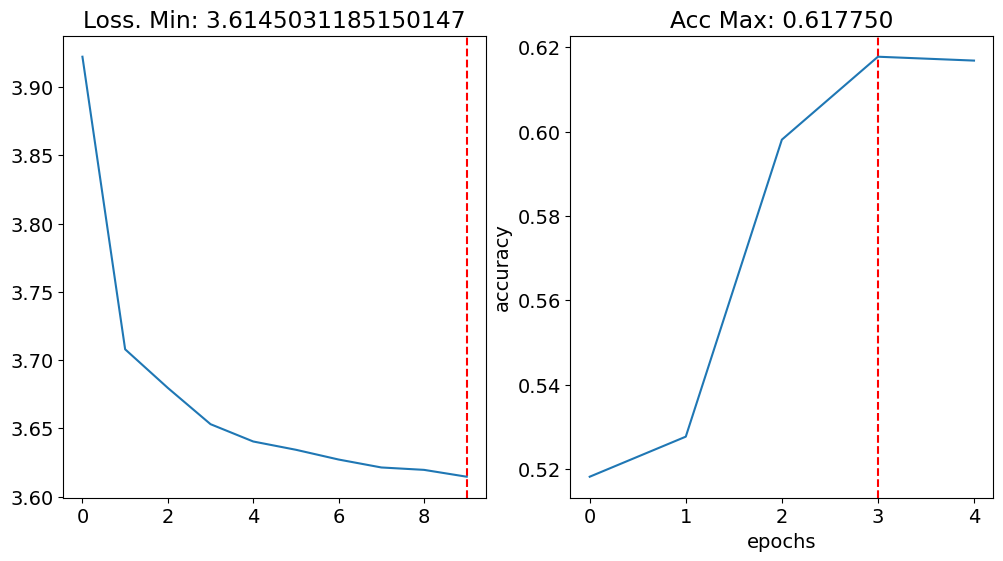

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

min_loss = np.argmin(losses_history)
ax[0].axvline(x=min_loss, color='r', linestyle='--')

ax[0].plot(losses_history, label="train_loss")
ax[0].set_title(f"Loss. Min: {min(losses_history)}")
plt.xlabel("epochs")
plt.ylabel("loss")


max_acc = np.argmax(accuracies_history)
ax[1].axvline(x=max_acc, color='r', linestyle='--')

ax[1].plot(accuracies_history, label="accuracies")
ax[1].set_title(f"Acc Max: {max(accuracies_history):4f}")
plt.xlabel("epochs")
plt.ylabel("accuracy")

fig.show()

Небольшой вывод: в данном случае accuracy меньше чем при обучении обычной supervised модели. Все потому, что здесь я брал только одну эпоху на валидацию с классификационной головой для экономии времени и ресурсов коллаба.

# Task 3(4 points)

Replace the InfoNCE loss in Multi-Format Contrastive Learning of Audio Representations with a Non-Contrastive Learning method.
Train the model until convergence, then plot the loss and accuracy curves to check that training has stabilized.

You can try one of the following NCL methods:
- BYOL([paper](https://arxiv.org/pdf/2006.07733))
- SimSiam([paper](https://arxiv.org/pdf/2011.10566))
- Barlow Twins([paper](https://arxiv.org/pdf/2103.03230))
- VicReg([paper](https://arxiv.org/pdf/2105.04906))

Feel free to use a more recent Non-Contrastive approach if you prefer—just explain briefly why you chose it.


Реализуем SimSiam

Описание:
SimSiam - неконтрастивный лосс, задача которого обучить хорошие представления ,без использования негативных пар, больших батчей, моментума. Цитата из статьи:

> simple Siamese networks can learn meaningful representations even using none of the following: (i) negative sample pairs, (ii) large batches, (iii) momentum encoders

Таким образом без использования способов выше, можно обучить модель создавать хорошие ембеддинги используя только стоп градиент и ассиметрию в структуре.

Ниже рализован SimSiam loss.

Описание параметров:

* Optimizer - в статье используется SGD Momentum. Может быть 5 лет назад это было и хорошо, но сейчас есть Adam. Думаю нет смысла описывать почему я выбрал его.
* Learning Rate - Из статьи: *lr = We use a learning rate of lr×BatchSize/256 , with a base lr = 0.05*. Но в нашем случае, т.к. мы используем Adam, то такой lr для него будет высоким. Поэтому возьмем стандартные 3e-4
* Projection MLP - нейросеть имеет 3 слоя, для каждого BatchNorm включая выходной, но для выходного не используется ReLU. В статье оригинальный MLP имеет размерность входа 2048, так как используется ResNet50. У нас модель попроще, используем ResNet18 и 512, итого 3 слоя: 512->256->128
* Prediction MLP - двухслойный линейный слой, нет ReLU и BatchNorm на выходе. В оригинальной статье также на входе имеет 2048 параметров, в нашем случае уменьшим их до 128.
* Количество эпох - в оригинальной статье это 100 эпох. Так мы конечно делать не будем, так как это займет слишком много времени. Возьмем например 10 эпох + early stopping по accuracy и по loss. Также, для валидации возьмем 2 эпохи.

In [32]:
def device_as(t1, t2):
   return t1.to(t2.device)

class SimSiam(nn.Module):
  def __init__(self):
    super().__init__()

    self.predictor = nn.Sequential(
    nn.Linear(128, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 128))

  def D(self, p, z):
    """
        Negative cosine similarity
    """

    z = z.detach() # stop gradient

    p = F.normalize(p, p=2, dim=1)
    z = F.normalize(z, p=2, dim=1)

    return -(p*z).sum(dim=1).mean()

  def forward(self, z1, z2):
    batch_size = z1.shape[0]

    # Prediction MLP
    p1 = self.predictor(z1)
    p2 = self.predictor(z2)

    loss = self.D(p1, z2)/2 + self.D(p2, z1)/2

    return loss

Модель.

In [33]:
class NonContrastiveNet(nn.Module):
    def __init__(self, img_channels = 1):
        super(NonContrastiveNet, self).__init__()
        ####################### ENCODER ###################################
        self.resnet_1D = CreateResNet1D()
        self.resnet_2D = CreateResNet2D(img_channels=img_channels)

        self.output = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128)
        )

        ####################################################################

    def forward(self, input_spectogram, input_audio=None):

        spectograms = self.resnet_2D(input_spectogram)
        spectograms = spectograms.squeeze(-1).squeeze(-1)
        specs_emb = self.output(spectograms)


        if input_audio is not None:
            audio = self.resnet_1D(input_audio)
            audio = audio.squeeze(-1)
            audio_emb = self.output(audio)
        else:
            audio = None
            audio_emb = None

        return audio_emb, specs_emb, audio, spectograms

Метод для создания модели

In [34]:
def create_noncontrastive(config):

  # Create model
  model = NonContrastiveNet(img_channels=config.IMG_CHANNEL).to(device)

  # Define the  loss
  criterion = SimSiam().to(device)

  #Define Melspectogram and STFT (Magnitude and Phase)
  mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128, n_mels=128, f_min=40, f_max=8000, mel_scale="slaney").to(device)

  # Define the optimizer, the paper use
  optimizer = torch.optim.Adam(model.parameters(), lr=config.LR, betas=(config.B1, config.B2))

  return model, criterion, optimizer, mel_transform

Код для обучения

Аугментации для SimSiam

In [35]:
def createModelInput(audio, mel_transform, stft_trasform=None, augmentation=True, simsiam=False):
    # [B, T] -> [B, 1, T]
    audio = audio.unsqueeze(1)

    def aug_pipeline(x):
        if not augmentation:
            return x
        y = x
        if random.random() < 0.7:
            y = fade_in_out(y)
        if random.random() < 0.7:
            y = timemasking(y, y.shape[0])
        if random.random() < 0.5:
            n_steps = random.randint(-4, 4)
            if n_steps != 0:
                y = pitchshift(y, SAMPLE_RATE=16000, shift=n_steps)
        if random.random() < 0.5:
            noise_level = random.uniform(0.0, 0.05)
            y = add_white_noise_(y, noise_level)
        return y

    if simsiam:
        # ДВЕ независимые аугментации одного и того же аудио
        audio1 = aug_pipeline(audio.clone())
        audio2 = aug_pipeline(audio.clone())

        # Mel-спектры
        spec1 = mel_transform(audio1)
        spec2 = mel_transform(audio2)

        # На device
        return spec1.to(device), audio1.to(device), spec2.to(device), audio2.to(device)

    # Обычный режим (одна версия)
    audio1 = aug_pipeline(audio)
    spec = mel_transform(audio1)
    return spec.to(device), audio1.to(device)

In [39]:
def train(model, closs, optimizer, trainloader, valloader, config, mel_transform, stft_trasform):

    scaler = torch.amp.GradScaler()

    losses_history = []
    accuracies_history = []
    clos_ = []

    # params for early stopping
    best_acc = 0
    best_epoch = -1
    best_state = None
    patience_cnt = 0
    PATIENCE = config.PATIENCE


    for epoch in range(config.EPOCHS):
        progress_bar = tqdm(total=len(trainloader), unit='step')

        epoch_loss = 0.0
        processed_data = 0

        for audio,lab in trainloader:
            optimizer.zero_grad()

            audio = audio.to(device)

            # take only specs from input
            spec1, aud1, spec2, aud2 = createModelInput(audio, mel_transform, simsiam=True, augmentation=True)

            with torch.amp.autocast(device_type="cuda", enabled=(device.type=="cuda")):
                _, s1, _, _ = model(spec1)
                _, s2, _, _ = model(spec2)

                loss = closs(s1, s2)


            # Calculate loss and backward
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            # progress bar stuff
            progress_bar.set_description(f"Epoch {epoch+1}/{config.EPOCHS}")
            progress_bar.set_postfix(loss=loss.item())  # Update the loss value
            progress_bar.update(1)

            # save loss to statistics
            epoch_loss += loss.item() * lab.size(0)
            processed_data += lab.size(0)


        # end for batch
        losses_history.append(epoch_loss/processed_data)

        # каждую вторую эпоху мы будем сохранять модель и производить оценку
        if epoch%2==0:
            # EVALUATION HEAD
            torch.save(model.state_dict(), f"models/model_{config.MODEL_TITLE}.pt")
            val_acc, model_head = evaluationphase(model, valloader, trainloader, config, mel_transform, stft_trasform)
            torch.save(model_head.state_dict(), f"models/model_{config.MODEL_TITLE}_head.pt")
            accuracies_history.append(val_acc)
        else:
            # чтобы не падать на нечётных эпохах
            val_acc = best_acc


        # --- EARLY STOPPING ---
        # если мы на нечетной эпохе, скипаем early stopping
        if epoch%2!=0:
            continue

        # 1. Validation accuracy
        if val_acc > best_acc + 1e-6:
            best_acc = val_acc
            best_epoch = epoch
            patience_cnt = 0
            best_state = {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": best_acc,
            }
            torch.save(best_state, os.path.join("models", f"best_{config.MODEL_TITLE}.pt"))
            tqdm.write(f"[best] epoch={epoch+1} val_acc={val_acc:.4f} — checkpoint saved")
        else:
            patience_cnt += 1
            tqdm.write(f"[no improve] epoch={epoch+1} val_acc={val_acc:.4f} | best={best_acc:.4f} ({patience_cnt}/{PATIENCE})")

        # 2.Covergence of loss

        tol = config.EARLY_STROPPING_COV
        converged = False
        if tol is not None and len(losses_history) >= 2:

            if np.std(losses_history[-2:]) < tol:
                converged = True
                tqdm.write(f"[converged by loss variance < tol={tol}] epoch={epoch+1}")

        if patience_cnt >= PATIENCE:
            tqdm.write(f"[early stop] no val_acc improvement for {PATIENCE} evals. best={best_acc:.4f} at epoch {best_epoch+1}")
            break

        if converged:
            tqdm.write(f"[early stop] train loss converged at epoch {epoch+1}")
            break

    return losses_history, accuracies_history


def evaluationphase(model, val_loader, trainloader, config, mel_transform, stft_trasform):

    model.eval()
    # Get dataloaders
    # Freeze the gradients for model1
    for param in model.parameters():
        param.requires_grad = False

    def train_head(model, trainloader):

        # Create model
        modelEvaluation = None
        modelEvaluation = EvaluationHead(num_classes = config.CLASSES).to(device)

        # Define the optimizer, the paper use
        optimizer = torch.optim.Adam(modelEvaluation.parameters(), lr=config.LR)

        criterion = torch.nn.CrossEntropyLoss()

        for epoch in range(config.EVAL_EPOCHS):
            progress_bar = tqdm(total=len(trainloader), unit='step', leave=False)
            losses = []
            for audio, labels in trainloader:
                optimizer.zero_grad()

                audio = audio.to(device)
                labels = labels.to(device)
                # Create augmentation and spectograms!
                spectograms, audios = createModelInput(audio, mel_transform, augmentation=False)

                # Use frozen encoder
                with torch.no_grad():
                    _, _, _, frozen_spects = model(spectograms, audios)

                outputs = modelEvaluation(frozen_spects)
                loss = criterion(outputs, labels)

                # Calculate loss and backward
                loss.backward()
                optimizer.step()

                losses.append(loss.item())

                #progress bar stuff
                progress_bar.set_description(f"Head tuning epoch {epoch+1}/{config.EVAL_EPOCHS}")
                progress_bar.set_postfix(loss=np.mean(losses))  # Update the loss value
                progress_bar.update(1)

            # end for batch

        return modelEvaluation

    def evaluation(model, model_eval, dataloader):
        model_eval.eval()
        progress_bar = tqdm(total=len(dataloader), unit='step')
        total = 0
        correct = 0
        with torch.no_grad():
            for i, (audio,labels) in enumerate(dataloader):

                audio = audio.to(device)
                spectograms, audios = createModelInput(audio, mel_transform,  augmentation=False)
                labels = labels.to(device)

                # Use frozen encoder
                _, _, _, frozen_spects = model(spectograms, audios)

                outputs = model_eval(frozen_spects)
                _, predicated = torch.max(outputs.data, 1)
                total += labels.size(0)

                correct += (predicated == labels).sum().item()

                #progress bar stuff
                progress_bar.set_description(f"Evaluation {i+1}/{len(dataloader)}")
                progress_bar.update(1)

            # end for batch

        return correct/total


    model_ = train_head(model, train_loader)
    accuracy_test = evaluation(model, model_, val_loader)
    print(f"Accuracy on validation: {accuracy_test}")
    model.train()
    for param in model.parameters():
        param.requires_grad = True

    return accuracy_test, model_


In [40]:
hyperparameters = {
        'LR': 3e-4,
        'WEIGHT_DECAY': 1e-6,
        'B1':0.9,
        'B2':0.999,
        'EPOCHS': 10,
        'BATCH_SIZE': 128,
        'IMG_CHANNEL': 1,
        'CLASSES': 10,
        'EVAL_BATCH':128,
        'EVAL_EPOCHS':1,
        'MODEL_TITLE': 'non_contrastive',
        "PATIENCE": 5,
        "EARLY_STROPPING_COV": 1e-5
}
config = DictConfig(hyperparameters)

## we use old loaders (uncomment if needed)
# Init dataloaders
train_loader = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader  = DataLoader(valid_ds,  batch_size=config.EVAL_BATCH, shuffle=False, collate_fn=collate)

#make the model, data and optimization problem
model, loss, optimizer, mel_transform = create_noncontrastive(config)

In [41]:
#train the model
losses_history, accuracies_history = train(model, loss, optimizer, train_loader, val_loader, config, mel_transform, None)

К сожалению на данном моменте у меня закончились ресурсы коллаба, дальнейшая работа невозможна(

# Task 4(2 points)

Evaluate and compare three training setups on the validation subset:

1. Supervised training

2. InfoNCE (contrastive learning)

3. Non-Contrastive Learning (NCL)

Use either the 2D or 1D encoder—or combine their embeddings.
Identify which setup performs best and explain why it outperforms the others.

1. Supervised training.

Для данного метода мы уже произвели валидацию ранее. Полученное accuracy - 0.979


2. InfoNCE (contrastive learning)

Мы возьмем обученную модель, в нее мы положим аудио и спектрограммы, получим эмбеддинги. Используя эти эмбеддинги обучим голову.

К сожалению ресурсов нет, не получилось сделать этот пункт((

3. Non-Contrastive Learning (NCL)
В связи с закончившимися ресурсами в коллабе, ничего тут не скажешь(